# LCR Resonant Circuit Analysis: Parallel Resistance
This notebook analyzes the frequency response and power Full Width at Half Maximum (FWHM) of a parallel LCR circuit.

By interpolating the FWHM for two different parallel resistances (19.1 kΩ and 57.6 kΩ) and performing a linear regression, one can derive the circuit's intrinsic capacitance ($C$), series resistance ($R_m$), and inductance ($L$).

In [38]:
import numpy as np
import matplotlib.pyplot as plt

## Data Initialization
The frequency and amplitude data for both parallel resistance configurations are defined as NumPy arrays. The parallel resistance values are also stored for later use in the linear regression analysis.

In [39]:
freq_19k = np.array([200802, 251487, 300365, 350350, 375480, 385594, 394906, 405547,
                     415623, 420509, 425402, 430369, 435661, 440204, 444936, 450382,
                     455545, 464984, 475195, 485142, 535705, 585134, 635630])
amp_19k = np.array([0.040, 0.024, 0.032, 0.041, 0.052, 0.064, 0.073, 0.091,
                    0.115, 0.131, 0.149, 0.170, 0.198, 0.218, 0.232, 0.230,
                    0.216, 0.172, 0.134, 0.108, 0.054, 0.043, 0.033])
Rp_19k = 19100.0

freq_57k = np.array([200737, 250650, 300400, 350774, 390928, 400587, 410749, 419924,
                     425067, 430310, 435542, 440717, 445222, 450150, 455197, 465253,
                     475113, 485256, 535418, 585433, 635175])
amp_57k = np.array([0.018, 0.024, 0.032, 0.050, 0.076, 0.088, 0.110, 0.146,
                    0.176, 0.220, 0.288, 0.382, 0.464, 0.462, 0.370, 0.224,
                    0.154, 0.116, 0.062, 0.044, 0.034])
Rp_57k = 57600.0

## FWHM Interpolation Algorithm
Instead of visually estimating the $V_{max} / \sqrt{2}$ crossing points from the raw data, this function linearly interpolates the exact frequencies where the amplitude crosses the power threshold. This significantly increases the precision of our bandwidth ($\Delta f$) extraction.

In [40]:
def calculate_fwhm(freq, amp):
    """Finds the FWHM (power) by linearly interpolating the crossing points."""
    max_amp = np.max(amp)
    fwhm_threshold = max_amp / np.sqrt(2) # Power FWHM threshold

    # Find exact frequencies where amplitude crosses the threshold
    crossings = []
    for i in range(len(amp) - 1):
        # Check if the threshold falls between two consecutive points
        if (amp[i] - fwhm_threshold) * (amp[i+1] - fwhm_threshold) <= 0:
            # Linear interpolation to find the exact x (frequency)
            x1, x2 = freq[i], freq[i+1]
            y1, y2 = amp[i], amp[i+1]
            x_cross = x1 + (fwhm_threshold - y1) * (x2 - x1) / (y2 - y1)
            crossings.append(x_cross)

    # Assuming standard resonance curve, we should have exactly 2 crossings
    if len(crossings) >= 2:
        f_lower, f_upper = crossings[0], crossings[-1]
        fwhm = f_upper - f_lower
        return fwhm, f_lower, f_upper, max_amp, fwhm_threshold
    else:
        return None, None, None, max_amp, fwhm_threshold


## Extracting FWHM Data
Here, the interpolation function is applied to both datasets to extract the $\Delta f$ values required for the linear regression step.

In [41]:
fwhm_19k, f1_19k, f2_19k, max_19k, thresh_19k = calculate_fwhm(freq_19k, amp_19k)
fwhm_57k, f1_57k, f2_57k, max_57k, thresh_57k = calculate_fwhm(freq_57k, amp_57k)

print("--- Interpolated FWHM Results ---")
print(f"Rp = 19.1 kOhm: FWHM = {fwhm_19k:.2f} Hz (Range: {f1_19k:.2f} to {f2_19k:.2f} Hz)")
print(f"Rp = 57.6 kOhm: FWHM = {fwhm_57k:.2f} Hz (Range: {f1_57k:.2f} to {f2_57k:.2f} Hz)\n")

--- Interpolated FWHM Results ---
Rp = 19.1 kOhm: FWHM = 38159.19 Hz (Range: 428961.39 to 467120.58 Hz)
Rp = 57.6 kOhm: FWHM = 20333.61 Hz (Range: 437749.50 to 458083.10 Hz)



## Linear Fit & Component Derivation
The theoretical relationship between the FWHM ($\Delta f$) and the parallel resistance ($R_p$) is given by:

$$\Delta f=\frac{1}{2\pi C}\left(\frac{1}{R_p}\right)+\frac{1}{2\pi C}\left(\frac{1}{R_m}\right)$$

This takes the form of a linear equation $y=mx+b$, where:
* **Slope ($m$)** = $\frac{1}{2\pi C}$
* **Y-Intercept ($b$)** = $\frac{1}{2\pi CR_m}$

By plotting $\Delta f$ against $1/R_p$, $C$ and $R_m$ can be extracted. Subsequently, the inductance ($L$) is calculated using the extracted capacitance and the theoretical resonance frequency ($\omega_0$).

In [42]:
# Prepare arrays for linear regression
# x-axis = 1 / Rp
# y-axis = FWHM (Delta f)
x_vals = np.array([1 / Rp_57k, 1 / Rp_19k])
y_vals = np.array([fwhm_57k, fwhm_19k])

# Fit a line (y = mx + b)
m, b = np.polyfit(x_vals, y_vals, 1)

# Physics calculations based on: Delta f = (1 / 2*pi*C)*(1/Rp) + (1 / 2*pi*C)*(1/Rm)
# y = m*x + b  ->  m = 1 / (2*pi*C)   ->  C = 1 / (2*pi*m)
#              ->  b = 1 / (2*pi*C*Rm)->  Rm = 1 / (2*pi*C*b) = m / b

C = 1 / (2 * np.pi * m)
Rm = m / b

# Calculate Inductance (L) from the resonance frequency (approx max)
f0 = freq_57k[np.argmax(amp_57k)]
omega_0 = 2 * np.pi * f0
L = 1 / ((omega_0 ** 2) * C)

print("--- Linear Fit & Derived Components ---")
print(f"Calculated Slope (m) : {m:.3e}")
print(f"Calculated Y-Int (b) : {b:.2f}")
print(f"Capacitance (C)      : {C*1e12:.2f} pF (Theoretical calc)")
print(f"Series Resist. (Rm)  : {Rm/1000:.2f} kOhm")
print(f"Inductance (L)       : {L*1000:.3f} mH")

--- Linear Fit & Derived Components ---
Calculated Slope (m) : 5.094e+08
Calculated Y-Int (b) : 11490.27
Capacitance (C)      : 312.45 pF (Theoretical calc)
Series Resist. (Rm)  : 44.33 kOhm
Inductance (L)       : 0.409 mH


## Visualizations
The plots below display the resonance curves with the interpolated FWHM boundaries highlighted, alongside the linear regression fit used to derive our components.

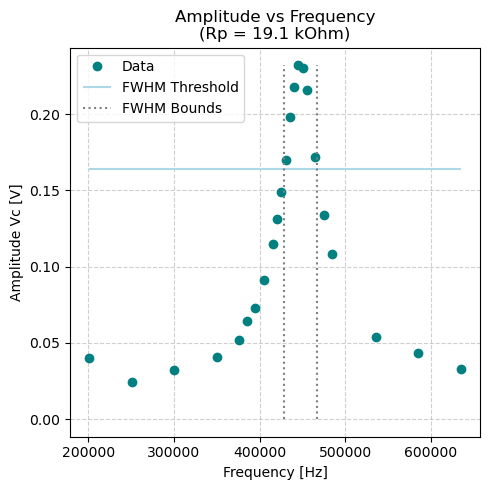

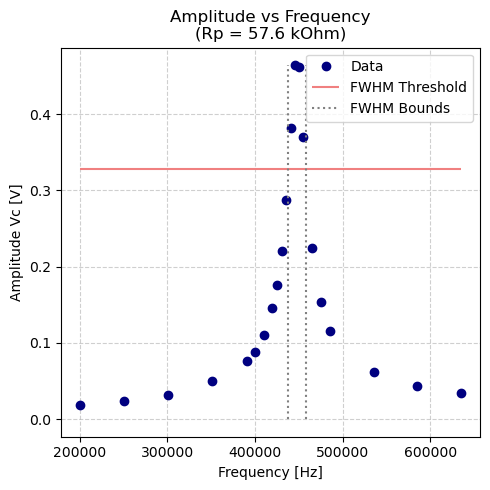

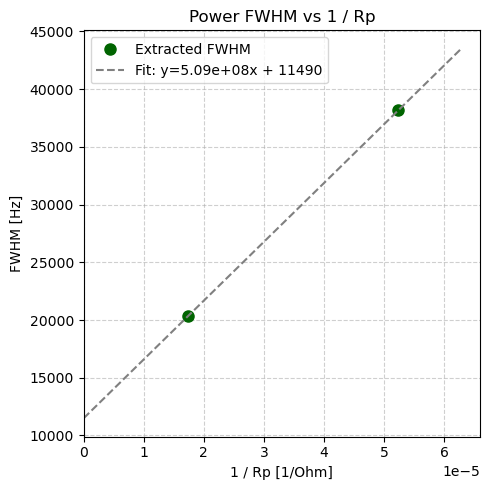

In [43]:
# Amplitude vs Frequency (19.1 kOhm)
plt.figure(figsize=(5, 5))
plt.plot(freq_19k, amp_19k, 'o', color='teal', label='Data')
plt.hlines(thresh_19k, freq_19k[0], freq_19k[-1], colors='lightblue', linestyles='solid', label='FWHM Threshold')
plt.vlines([f1_19k, f2_19k], ymin=0, ymax=np.max(amp_19k), colors='gray', linestyles=':', label='FWHM Bounds')
plt.title('Amplitude vs Frequency\n(Rp = 19.1 kOhm)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude Vc [V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('Amplitude_vs_Frequency_19kOhm.png', dpi=300)  # Save the figure
plt.show()

# Amplitude vs Frequency (57.6 kOhm)
plt.figure(figsize=(5, 5))
plt.plot(freq_57k, amp_57k, 'o', color='navy', label='Data')
plt.hlines(thresh_57k, freq_57k[0], freq_57k[-1], colors='lightcoral', linestyles='solid', label='FWHM Threshold')
plt.vlines([f1_57k, f2_57k], ymin=0, ymax=np.max(amp_57k), colors='gray', linestyles=':', label='FWHM Bounds')
plt.title('Amplitude vs Frequency\n(Rp = 57.6 kOhm)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude Vc [V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('Amplitude_vs_Frequency_57kOhm.png', dpi=300)  # Save the figure
plt.show()

# FWHM vs 1/Rp with Linear Fit
plt.figure(figsize=(5, 5))
plt.plot(x_vals, y_vals, 'o', color='darkgreen', markersize=8, label='Extracted FWHM')
x_fit = np.linspace(0, max(x_vals)*1.2, 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, '--', color='grey', label=f'Fit: y={m:.2e}x + {b:.0f}')
plt.title('Power FWHM vs 1 / Rp')
plt.xlabel('1 / Rp [1/Ohm]')
plt.ylabel('FWHM [Hz]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(left=0)
plt.tight_layout()
plt.savefig('Power_FWHM_vs_Rp', dpi=300)  # Save the figure
plt.show()